In [1]:
import xarray as xr
from pathlib import Path

In [2]:
sims = ["UBI", "ERA5", "UBB", "UBD", "UBE", "UBF", "UBG", "UBH"]
seasons = ["ALL", "DJF", "MAM", "JJA", "SON"]

base_dir = Path("/project/rrg-gachon/vdemeyer")

# -----------------------------
# Boucle sur toutes les simulations
# -----------------------------
for sim in sims:
    input_dir = base_dir / sim / "DENSITY"
    output_file = input_dir / f"density_ETCs_center_{sim.lower()}_all_seasons.nc"
    
    print(f"Processing simulation: {sim}")

    data_arrays = []
    
    for season in seasons:
        nc_file = input_dir / f"density_ETCs_center_{sim.lower()}_{season}.nc"
        if not nc_file.exists():
            print(f"  Warning: fichier manquant pour {season}, skipped.")
            continue
        
        ds = xr.open_dataset(nc_file)
        da = ds["density_ETCs"]
        
        # Ajouter dimension saison
        da = da.expand_dims("season")
        da = da.assign_coords(season=[season])
        
        data_arrays.append(da)
    
    if not data_arrays:
        print(f"  Aucun fichier trouvé pour {sim}, skipping.")
        continue
    
    # Concaténation sur la dimension season
    combined = xr.concat(data_arrays, dim="season")
    
    # Sauvegarde NetCDF unique
    combined.to_netcdf(output_file)
    print(f"  NetCDF combiné sauvegardé : {output_file}\n")

Processing simulation: UBI
  NetCDF combiné sauvegardé : /project/rrg-gachon/vdemeyer/UBI/DENSITY/density_ETCs_center_ubi_all_seasons.nc

Processing simulation: ERA5
  NetCDF combiné sauvegardé : /project/rrg-gachon/vdemeyer/ERA5/DENSITY/density_ETCs_center_era5_all_seasons.nc

Processing simulation: UBB
  NetCDF combiné sauvegardé : /project/rrg-gachon/vdemeyer/UBB/DENSITY/density_ETCs_center_ubb_all_seasons.nc

Processing simulation: UBD
  NetCDF combiné sauvegardé : /project/rrg-gachon/vdemeyer/UBD/DENSITY/density_ETCs_center_ubd_all_seasons.nc

Processing simulation: UBE
  NetCDF combiné sauvegardé : /project/rrg-gachon/vdemeyer/UBE/DENSITY/density_ETCs_center_ube_all_seasons.nc

Processing simulation: UBF
  NetCDF combiné sauvegardé : /project/rrg-gachon/vdemeyer/UBF/DENSITY/density_ETCs_center_ubf_all_seasons.nc

Processing simulation: UBG
  NetCDF combiné sauvegardé : /project/rrg-gachon/vdemeyer/UBG/DENSITY/density_ETCs_center_ubg_all_seasons.nc

Processing simulation: UBH
  Ne

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import matplotlib
import numpy as np

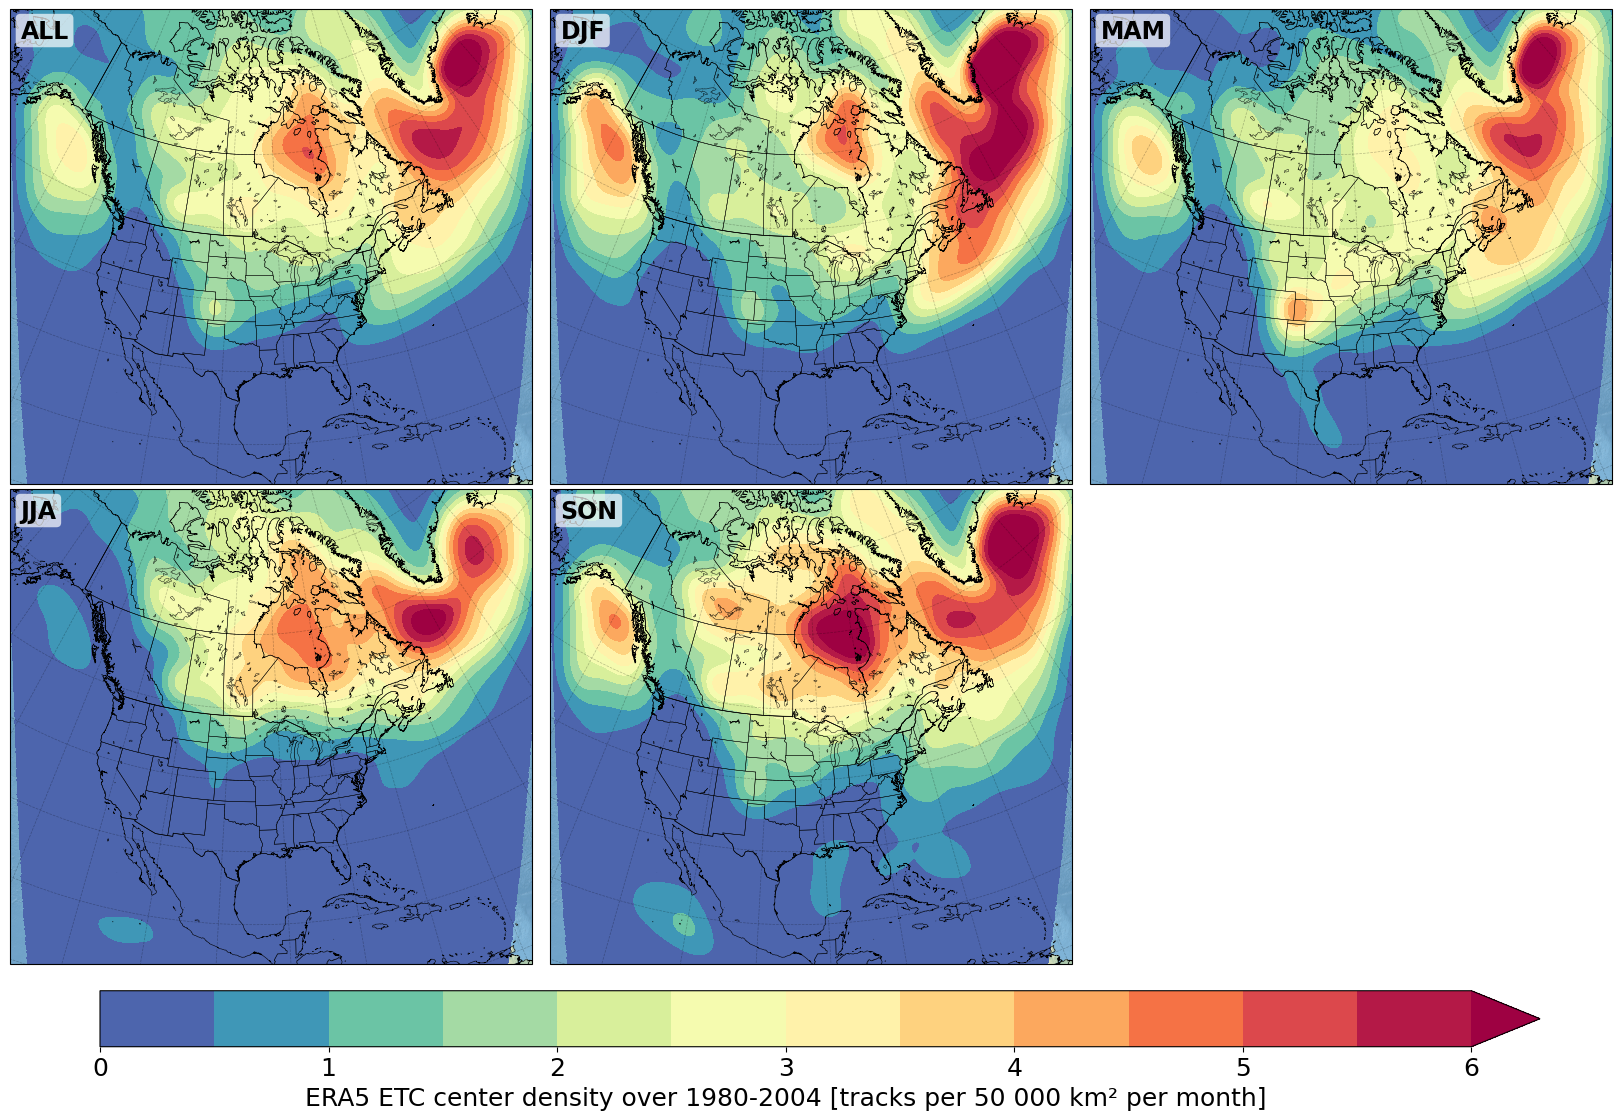

In [5]:
positions = [
    [0.05, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 1
    [0.35, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 2
    [0.65, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 3
    [0.05, 0.18, 0.29, 0.50],  # Rangée du bas, Colonne 1
    [0.35, 0.18, 0.29, 0.50],  # Rangée du bas, Colonne 2
    # [0.65, 0.11, 0.29, 0.50],  # Rangée du bas,  Colonne 3
]

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 16))
axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

vmin = 0
vmax = 6.
step = 0.5

sim = 'ERA5'
base_dir = Path("/project/rrg-gachon/vdemeyer")
input_dir = base_dir / sim / "DENSITY"
seasons = ["ALL", "DJF", "MAM", "JJA", "SON"]

for i, (ax, season) in enumerate(zip(axes, seasons)):
    
    nc_file = input_dir / f"density_ETCs_center_{sim.lower()}_{season}.nc"
    ds = xr.open_dataset(nc_file)
    
    ax.set_extent([-128, -57, 75, 14], crs=ccrs.PlateCarree())
    # ax.set_extent([-168, -27, 85, 5], crs=ccrs.PlateCarree())
    borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
    states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
    lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
    lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
    img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
    ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
    ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
    ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
    ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())
    
    density_masked = np.ma.masked_where(ds.density_ETCs <= 0, ds.density_ETCs)
    
    sc = ax.contourf(
        ds.longitude, ds.latitude, ds.density_ETCs * 50000.,
        transform=ccrs.PlateCarree(),
        levels=np.arange(vmin, vmax+step, step),
        cmap='Spectral_r',
        extend='max'
    )
    
    ax.text(0.02, 0.98, season, transform=ax.transAxes, fontsize=17, fontweight='bold',
            ha='left', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

cbar_ax = fig.add_axes([0.1, 0.23, 0.8, 0.035])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, aspect=50, extend='max')
cbar.set_label("ERA5 ETC center density over 1980-2004 [tracks per 50 000 km² per month]", fontsize=18)
cbar.ax.tick_params(labelsize=18)

In [24]:
coord_path = f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/PR_Percentile/pr_era5_CORDEX_NA_percentile_1980-2004.nc'
for_coord = xr.open_dataset(coord_path)
for_coord

<xarray.Dataset> Size: 8MB
Dimensions:    (latitude: 322, longitude: 732, quantile: 4)
Coordinates:
  * latitude   (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * longitude  (longitude) float32 3kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * quantile   (quantile) float64 32B 0.98 0.99 0.995 0.999
Data variables:
    pr         (quantile, latitude, longitude) float64 8MB ...

In [25]:
mask = xr.open_dataarray('/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/mask_CRCM6_grid_for_ERA5.nc')
mask = mask.reindex_like(for_coord, method='nearest')
mask

<xarray.DataArray (latitude: 322, longitude: 732)> Size: 236kB
[235704 values with dtype=bool]
Coordinates:
  * latitude   (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * longitude  (longitude) float32 3kB -180.0 -179.8 -179.5 ... 179.5 179.8

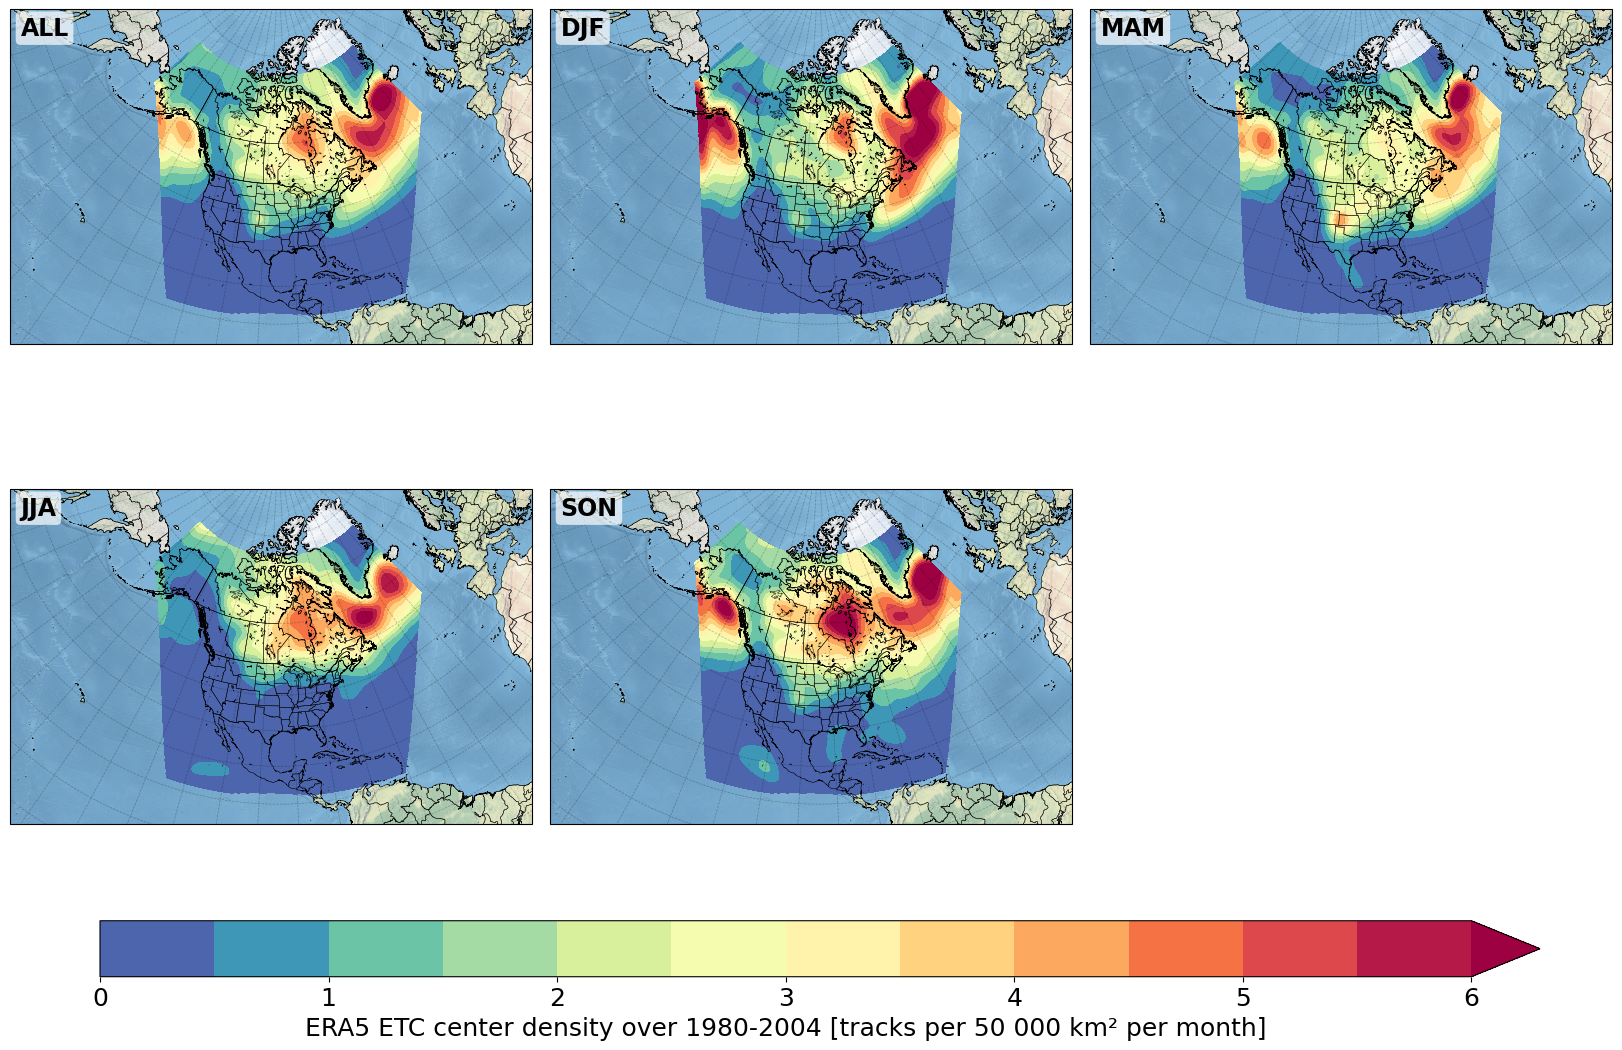

In [26]:
positions = [
    [0.05, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 1
    [0.35, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 2
    [0.65, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 3
    [0.05, 0.18, 0.29, 0.50],  # Rangée du bas, Colonne 1
    [0.35, 0.18, 0.29, 0.50],  # Rangée du bas, Colonne 2
    # [0.65, 0.11, 0.29, 0.50],  # Rangée du bas,  Colonne 3
]

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 16))
axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

vmin = 0
vmax = 6.
step = 0.5

sim = 'ERA5'
base_dir = Path("/project/rrg-gachon/vdemeyer")
input_dir = base_dir / sim / "DENSITY"
seasons = ["ALL", "DJF", "MAM", "JJA", "SON"]

for i, (ax, season) in enumerate(zip(axes, seasons)):
    
    nc_file = input_dir / f"density_ETCs_center_{sim.lower()}_{season}.nc"
    ds = xr.open_dataset(nc_file)
    
    # ax.set_extent([-128, -57, 75, 14], crs=ccrs.PlateCarree())
    ax.set_extent([-168, -27, 85, 5], crs=ccrs.PlateCarree())
    borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
    states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
    lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
    lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
    img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
    ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
    ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
    ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
    ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())
    
    sc = ax.contourf(
        ds.longitude, ds.latitude, ds.density_ETCs.where(mask, drop=True) * 50000.,
        transform=ccrs.PlateCarree(),
        levels=np.arange(vmin, vmax+step, step),
        cmap='Spectral_r',
        extend='max'
    )
    
    ax.text(0.02, 0.98, season, transform=ax.transAxes, fontsize=17, fontweight='bold',
            ha='left', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

cbar_ax = fig.add_axes([0.1, 0.23, 0.8, 0.035])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, aspect=50, extend='max')
cbar.set_label("ERA5 ETC center density over 1980-2004 [tracks per 50 000 km² per month]", fontsize=18)
cbar.ax.tick_params(labelsize=18)